In [28]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG19, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [33]:
DATA_DIR = Path(r"D:\Desktop\Braille Dataset\Braille Dataset")

def parse_filename(fname):
    m = re.match(r"([a-z])1\.JPG(\d+)(dim|rot|whs)\.jpg", fname)
    if m:
        return m.group(1), m.group(3), int(m.group(2))
    return None, None, None

def load_dataset(data_dir, img_size=(28, 28)):
    images, labels, augs = [], [], []
    for fname in sorted(os.listdir(data_dir)):
        if not fname.endswith(".jpg"):
            continue
        label, aug, _ = parse_filename(fname)
        if label is None:
            continue
        img = Image.open(data_dir / fname).convert("L")
        img = img.resize(img_size)
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(label)
        augs.append(aug)
    return np.array(images), np.array(labels), np.array(augs)

X, y_str, aug_arr = load_dataset(DATA_DIR)
print(f"Images: {len(X)}  |  Shape: {X.shape}  |  Classes: {np.unique(y_str)}")
DATA_DIR = Path(r"D:\Desktop\Braille Dataset")

Images: 1560  |  Shape: (1560, 28, 28)  |  Classes: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


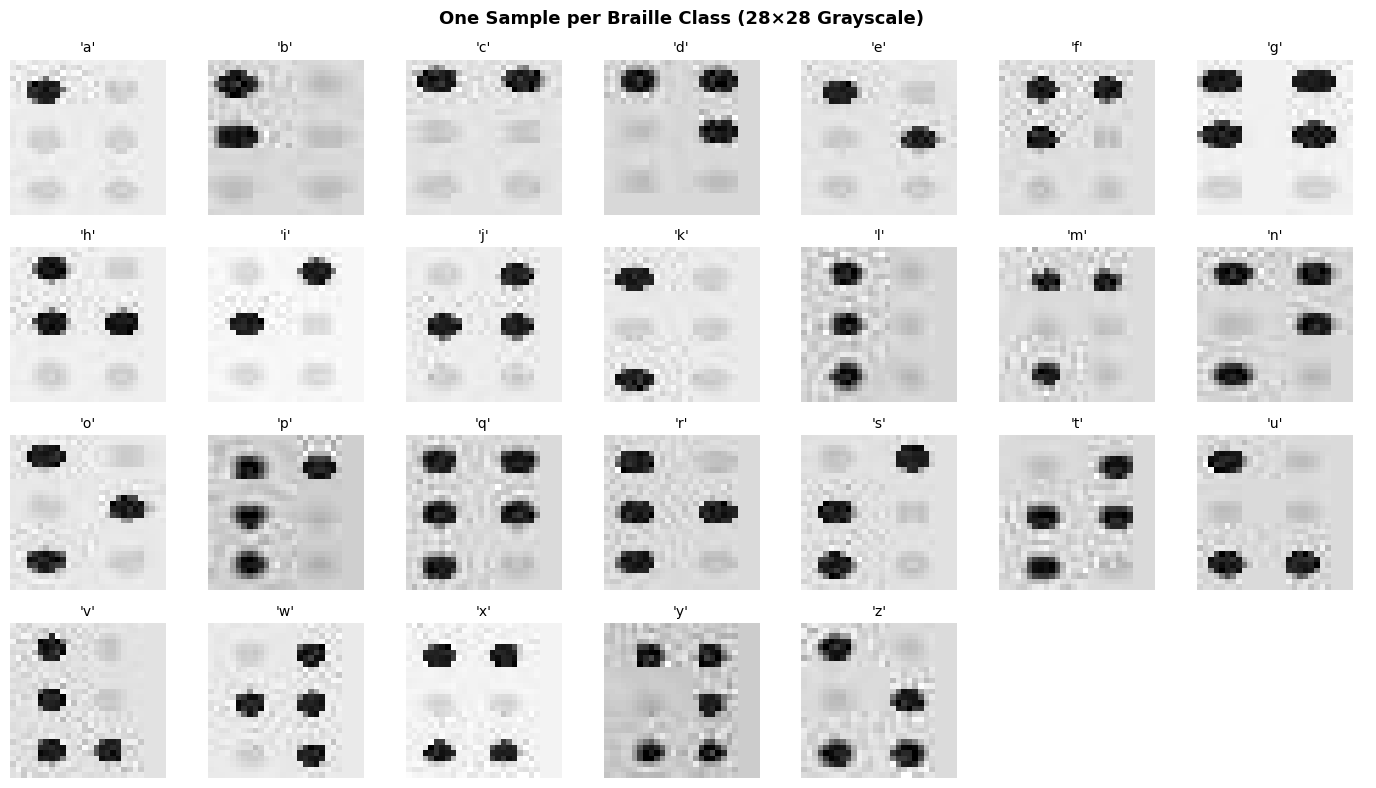

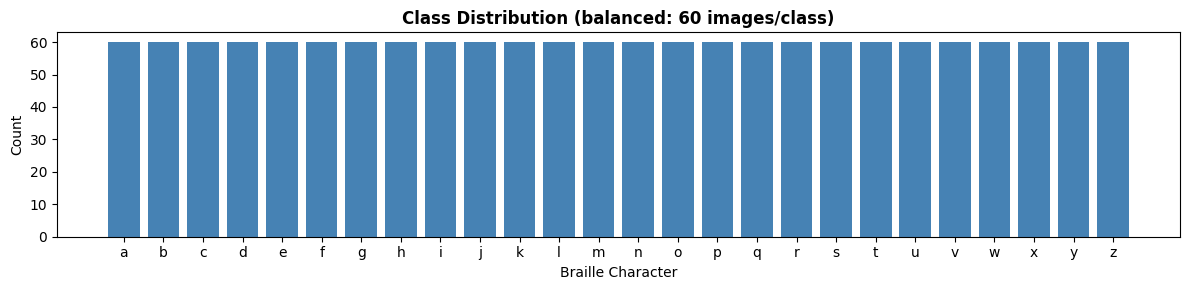

In [34]:
le = LabelEncoder()
y = le.fit_transform(y_str)
NUM_CLASSES = len(le.classes_)

# One sample per class
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
fig.suptitle("One Sample per Braille Class (28×28 Grayscale)", fontsize=13, fontweight="bold")
for ax, cls in zip(axes.flat, le.classes_):
    idx = np.where(y_str == cls)[0][0]
    ax.imshow(X[idx], cmap="gray")
    ax.set_title(f"'{cls}'", fontsize=10)
    ax.axis("off")
for ax in axes.flat[26:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Class distribution
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(12, 3))
plt.bar(le.classes_, counts, color="steelblue")
plt.title("Class Distribution (balanced: 60 images/class)", fontweight="bold")
plt.xlabel("Braille Character"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

In [35]:
# Step 1: hold out 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Step 2: split remaining into 70% train + 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Train : {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val)}   ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test)}   ({len(X_test)/len(X)*100:.1f}%)")
print(f"Class balance — min: {np.bincount(y_train).min()}  max: {np.bincount(y_train).max()}")

Train : 1091  (69.9%)
Val   : 235   (15.1%)
Test  : 234   (15.0%)
Class balance — min: 41  max: 42


In [36]:
X_flat_train = X_train.reshape(len(X_train), -1)
X_flat_val   = X_val.reshape(len(X_val),   -1)
X_flat_test  = X_test.reshape(len(X_test),  -1)

pca = PCA(n_components=100, random_state=42)
X_pca_train = pca.fit_transform(X_flat_train)
X_pca_val   = pca.transform(X_flat_val)
X_pca_test  = pca.transform(X_flat_test)

print(f"Explained variance (100 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%")

svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_pca_train, y_train)

svm_val_pred  = svm.predict(X_pca_val)
svm_test_pred = svm.predict(X_pca_test)

svm_val_acc  = accuracy_score(y_val,  svm_val_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)
svm_test_f1  = f1_score(y_test, svm_test_pred, average="macro")

print(f"Val  Accuracy : {svm_val_acc*100:.2f}%")
print(f"Test Accuracy : {svm_test_acc*100:.2f}%")
print(f"Test Macro-F1 : {svm_test_f1*100:.2f}%")
print(classification_report(y_test, svm_test_pred, target_names=le.classes_))

Explained variance (100 PCs): 97.2%
Val  Accuracy : 78.30%
Test Accuracy : 79.06%
Test Macro-F1 : 78.48%
              precision    recall  f1-score   support

           a       0.90      1.00      0.95         9
           b       0.88      0.78      0.82         9
           c       0.67      0.67      0.67         9
           d       0.71      0.56      0.62         9
           e       0.82      1.00      0.90         9
           f       0.47      0.78      0.58         9
           g       0.89      0.89      0.89         9
           h       0.88      0.78      0.82         9
           i       0.73      0.89      0.80         9
           j       0.67      0.89      0.76         9
           k       0.73      0.89      0.80         9
           l       0.58      0.78      0.67         9
           m       0.78      0.78      0.78         9
           n       0.80      0.89      0.84         9
           o       0.88      0.78      0.82         9
           p       0.50      0

In [37]:
# CNN input: add channel dim
X_cnn_train = X_train[..., np.newaxis]   # (N, 28, 28, 1)
X_cnn_val   = X_val[...,   np.newaxis]
X_cnn_test  = X_test[...,  np.newaxis]

# Pretrained models: resize to 48×48 RGB
def resize_to_rgb(X_gray, size=(48, 48)):
    out = []
    for img in X_gray:
        pil = Image.fromarray((img * 255).astype(np.uint8)).convert("RGB")
        pil = pil.resize(size, Image.BILINEAR)
        out.append(np.array(pil, dtype=np.float32) / 255.0)
    return np.array(out)

print("Resizing to 48×48 RGB ...")
X48_train = resize_to_rgb(X_train)
X48_val   = resize_to_rgb(X_val)
X48_test  = resize_to_rgb(X_test)
print(f"Shape: {X48_train.shape}")

Resizing to 48×48 RGB ...
Shape: (1091, 48, 48, 3)


In [38]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, verbose=1)
]

In [39]:
def build_custom_cnn(input_shape=(28, 28, 1), num_classes=26):
    inp = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inp, out, name="CustomCNN")

cnn = build_custom_cnn()
cnn.summary()

cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

hist_cnn = cnn.fit(
    X_cnn_train, y_train,
    validation_data=(X_cnn_val, y_val),
    epochs=60, batch_size=32,
    callbacks=callbacks
)

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,274 (520.60 KB)

 Trainable params: 132,826 (518.85 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.0632 - loss: 3.2347 - val_accuracy: 0.0383 - val_loss: 3.2945 - learning_rate: 0.0010
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0926 - loss: 3.0051 - val_accuracy: 0.0383 - val_loss: 4.0047 - learning_rate: 0.0010
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.1265 - loss: 2.8490 - val_accuracy: 0.0383 - val_loss: 5.7888 - learning_rate: 0.0010
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1577 - loss: 2.7220 - val_accuracy: 0.0383 - val_loss: 7.3690 - learning_rate: 0.0010
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1998 - loss: 2.5774 - val_accuracy: 0.0383 - val_loss: 9.3034 - learning_rate: 0.0010
Epoch 6/60
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2155 - loss: 2.5020
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2319 - loss: 2.4647 - val_accu

In [40]:
def build_vgg19_transfer(input_shape=(48, 48, 3), num_classes=26):
    base = VGG19(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation="relu")(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="VGG19_Transfer")

vgg = build_vgg19_transfer()

# Phase 1: Feature extraction
vgg.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
print("Phase 1: Training head only ...")
vgg.fit(X48_train, y_train, validation_data=(X48_val, y_val),
        epochs=30, batch_size=32, callbacks=callbacks)

# Phase 2: Fine-tune top conv blocks
base_vgg = vgg.get_layer("vgg19")
base_vgg.trainable = True
for layer in base_vgg.layers[:15]:
    layer.trainable = False

vgg.compile(optimizer=keras.optimizers.Adam(1e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
print("\nPhase 2: Fine-tuning layers 15+ ...")
hist_vgg = vgg.fit(X48_train, y_train, validation_data=(X48_val, y_val),
                   epochs=20, batch_size=32, callbacks=callbacks)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step
Phase 1: Training head only ...
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.1558 - loss: 3.0046 - val_accuracy: 0.4553 - val_loss: 2.4206 - learning_rate: 0.0010
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.3611 - loss: 2.2197 - val_accuracy: 0.5362 - val_loss: 1.9203 - learning_rate: 0.0010
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step - accuracy: 0.4849 - loss: 1.8082 - val_accuracy: 0.5277 - val_loss: 1.6471 - learning_rate: 0.0010
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 355ms/step - accuracy: 0.5325 - loss: 1.5713 - val_accuracy: 0.6255 - val_loss: 1.4508 - learning_rate: 0.0010
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - accuracy: 0.6040 - loss: 1.3749 - val_accuracy: 0.6638 - val_loss: 1.3136 - learning_rate: 0.0010
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 509ms/step - accuracy: 0.6618 - loss: 1.2012 - val_accuracy: 0.6936 - val_loss: 1.1678 - learning_rate: 0.0010


In [41]:
def build_resnet50_transfer(input_shape=(48, 48, 3), num_classes=26):
    base = ResNet50(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation="relu")(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="ResNet50_Transfer")

rn = build_resnet50_transfer()

# Phase 1: Feature extraction
rn.compile(optimizer=keras.optimizers.Adam(1e-3),
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])
print("Phase 1: Training head only ...")
rn.fit(X48_train, y_train, validation_data=(X48_val, y_val),
       epochs=30, batch_size=32, callbacks=callbacks)

# Phase 2: Fine-tune last residual block
base_rn = rn.get_layer("resnet50")
base_rn.trainable = True
for layer in base_rn.layers[:143]:
    layer.trainable = False

rn.compile(optimizer=keras.optimizers.Adam(1e-5),
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])
print("\nPhase 2: Fine-tuning layers 143+ ...")
hist_rn = rn.fit(X48_train, y_train, validation_data=(X48_val, y_val),
                 epochs=20, batch_size=32, callbacks=callbacks)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step
Phase 1: Training head only ...
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.0559 - loss: 3.4278 - val_accuracy: 0.1064 - val_loss: 3.1538 - learning_rate: 0.0010
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.0697 - loss: 3.1696 - val_accuracy: 0.1702 - val_loss: 3.0843 - learning_rate: 0.0010
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.0935 - loss: 3.1058 - val_accuracy: 0.1064 - val_loss: 3.0329 - learning_rate: 0.0010
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.1311 - loss: 3.0356 - val_accuracy: 0.1745 - val_loss: 2.9400 - learning_rate: 0.0010
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.1381 - loss: 2.9760
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.1412 - loss: 2.9610 - val_accuracy: 0.2213 - val_loss: 2.8594 - learning_rate: 0.0010
Epoc

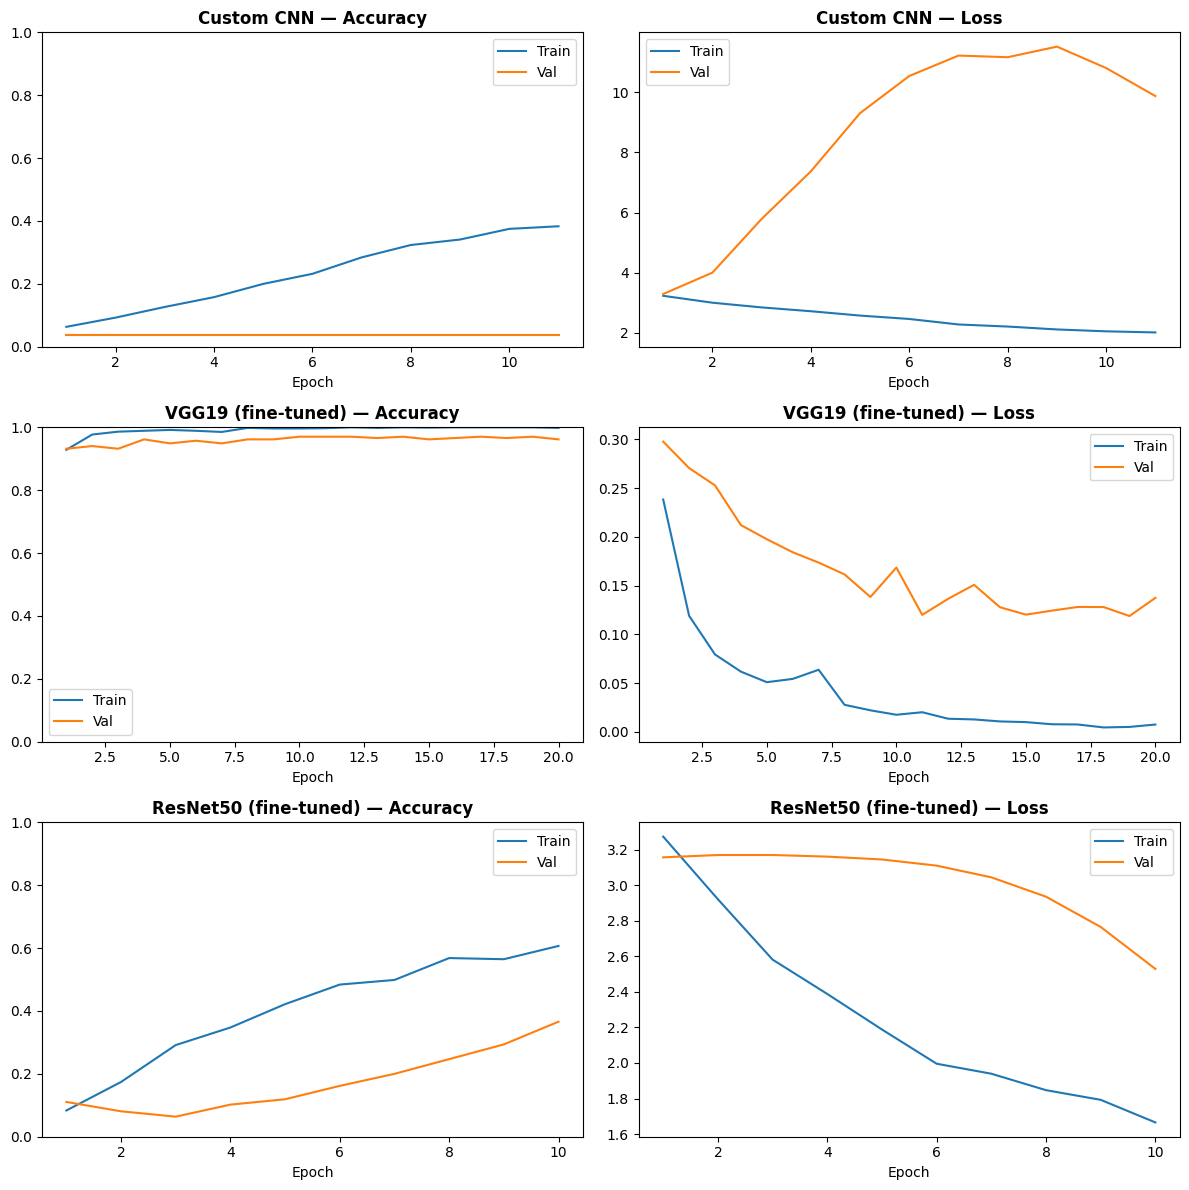

In [42]:
def plot_history(hist, title, ax_acc, ax_loss):
    ep = range(1, len(hist.history["accuracy"]) + 1)
    ax_acc.plot(ep, hist.history["accuracy"],     label="Train")
    ax_acc.plot(ep, hist.history["val_accuracy"], label="Val")
    ax_acc.set_title(f"{title} — Accuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch"); ax_acc.legend(); ax_acc.set_ylim(0, 1)
    ax_loss.plot(ep, hist.history["loss"],     label="Train")
    ax_loss.plot(ep, hist.history["val_loss"], label="Val")
    ax_loss.set_title(f"{title} — Loss", fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.legend()

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
plot_history(hist_cnn, "Custom CNN",           axes[0, 0], axes[0, 1])
plot_history(hist_vgg, "VGG19 (fine-tuned)",   axes[1, 0], axes[1, 1])
plot_history(hist_rn,  "ResNet50 (fine-tuned)", axes[2, 0], axes[2, 1])
plt.tight_layout()
plt.show()

In [43]:
cnn_pred = np.argmax(cnn.predict(X_cnn_test), axis=1)
vgg_pred = np.argmax(vgg.predict(X48_test),   axis=1)
rn_pred  = np.argmax(rn.predict(X48_test),    axis=1)

print(f"{'Model':<25} {'Test Acc':>10} {'Test F1':>10}")
print("-"*47)
rows = [
    ("SVM + PCA (baseline)", svm_test_pred),
    ("Custom CNN",           cnn_pred),
    ("VGG19 (Transfer)",     vgg_pred),
    ("ResNet50 (Transfer)",  rn_pred),
]
for name, pred in rows:
    acc = accuracy_score(y_test, pred) * 100
    f1  = f1_score(y_test, pred, average="macro") * 100
    print(f"{name:<25} {acc:>9.2f}% {f1:>9.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 243ms/step
Model                       Test Acc    Test F1
-----------------------------------------------
SVM + PCA (baseline)          79.06%     78.48%
Custom CNN                     3.85%      0.28%
VGG19 (Transfer)              96.15%     96.12%
ResNet50 (Transfer)            8.97%      4.45%


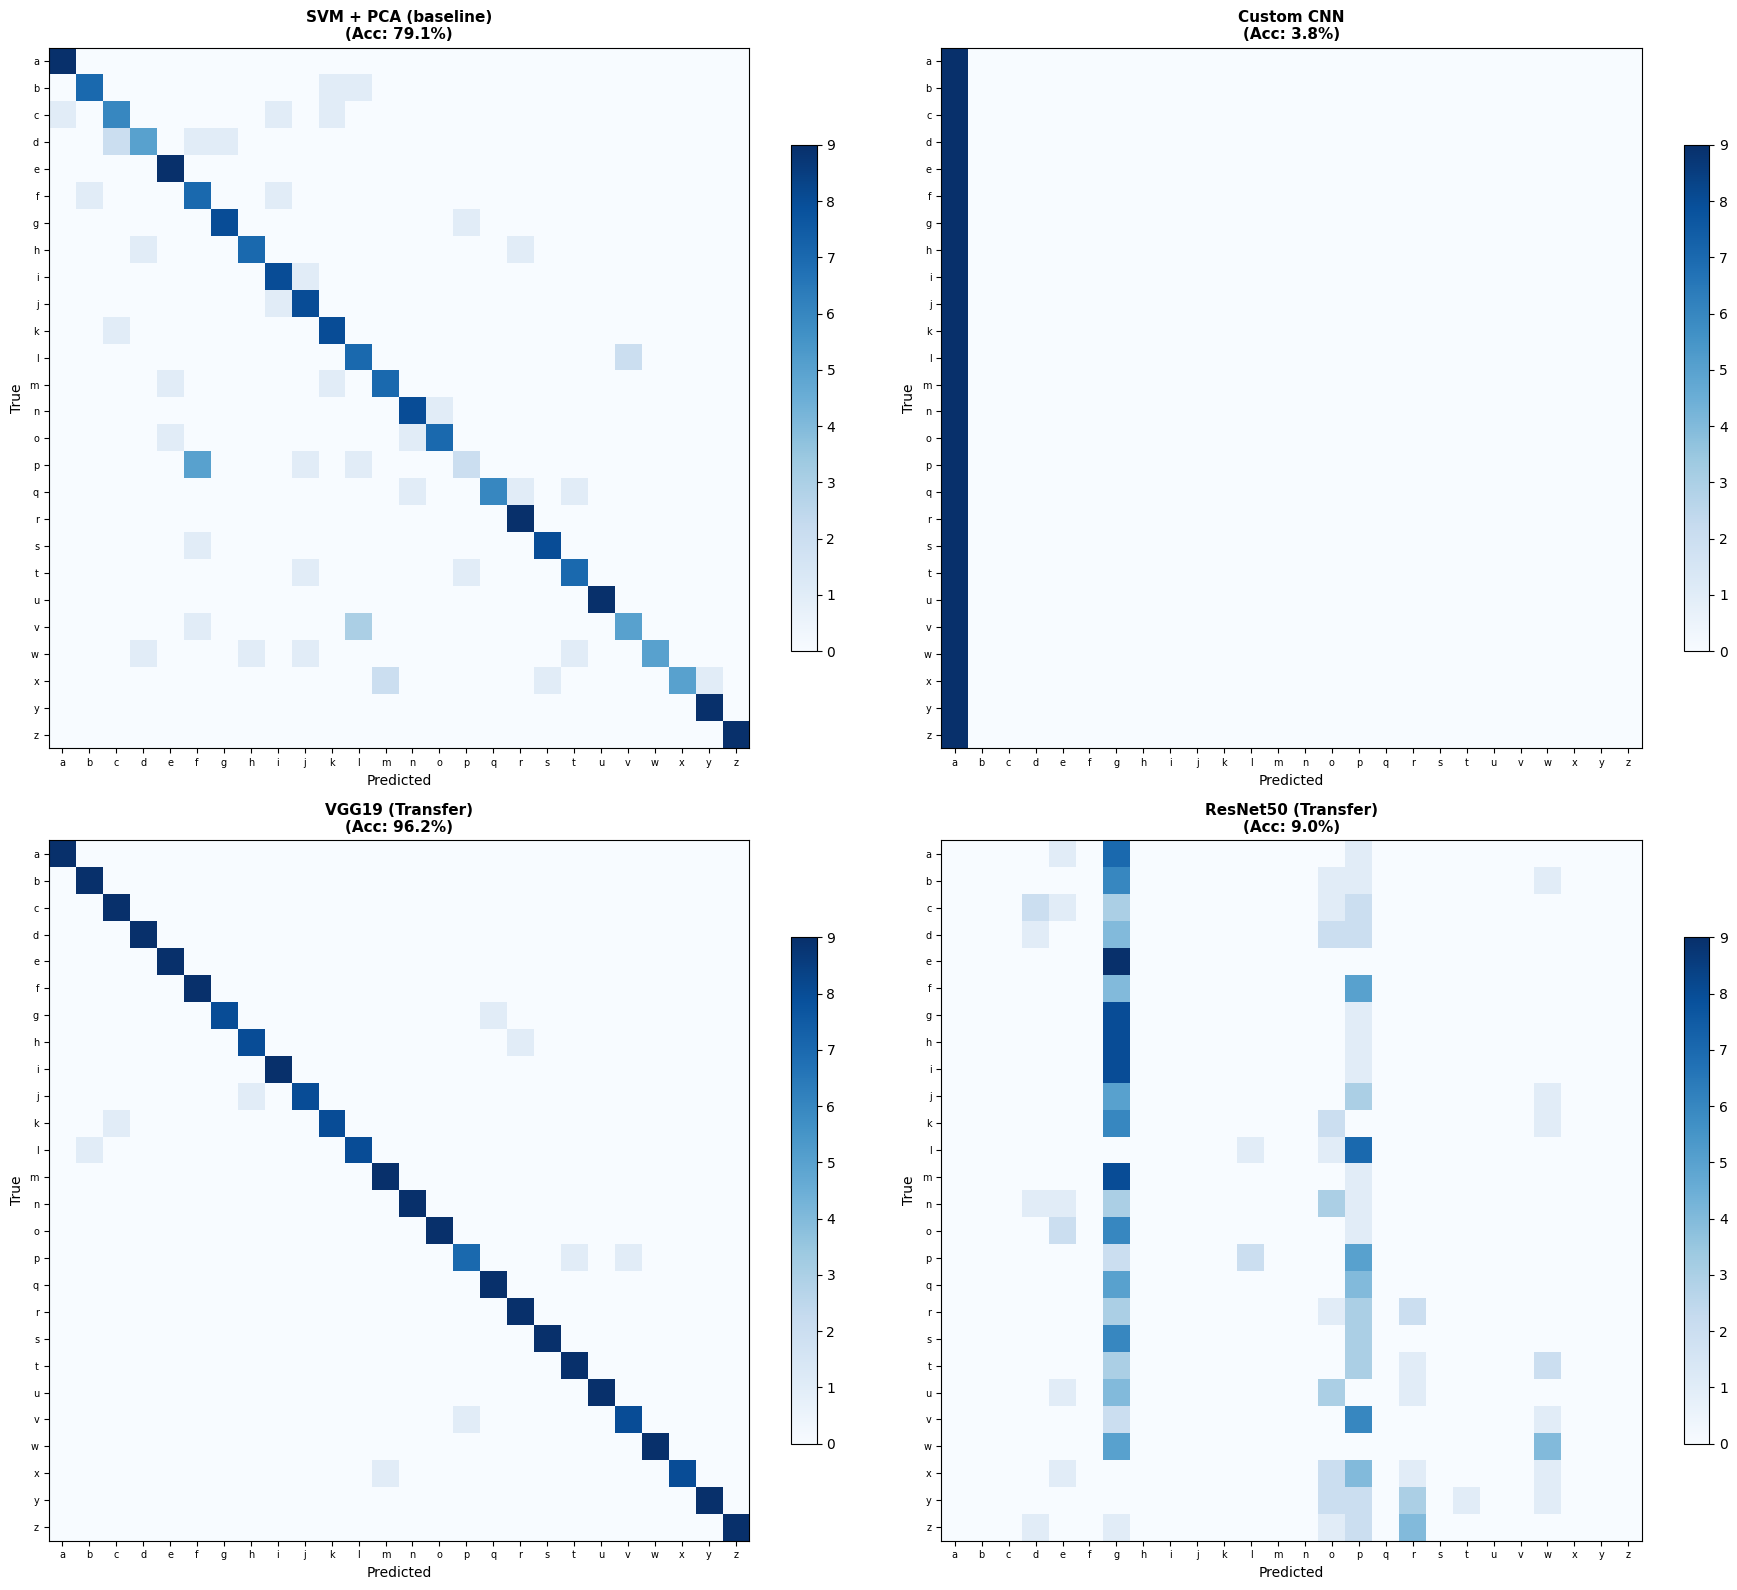

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
for ax, (name, pred) in zip(axes.flat, rows):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\n(Acc: {accuracy_score(y_test,pred)*100:.1f}%)",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(range(26)); ax.set_xticklabels(list(le.classes_), fontsize=7)
    ax.set_yticks(range(26)); ax.set_yticklabels(list(le.classes_), fontsize=7)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [45]:
for name, pred in rows:
    print(f"\n{'='*55}")
    print(f"{name} — Classification Report")
    print("="*55)
    print(classification_report(y_test, pred, target_names=le.classes_))


SVM + PCA (baseline) — Classification Report
              precision    recall  f1-score   support

           a       0.90      1.00      0.95         9
           b       0.88      0.78      0.82         9
           c       0.67      0.67      0.67         9
           d       0.71      0.56      0.62         9
           e       0.82      1.00      0.90         9
           f       0.47      0.78      0.58         9
           g       0.89      0.89      0.89         9
           h       0.88      0.78      0.82         9
           i       0.73      0.89      0.80         9
           j       0.67      0.89      0.76         9
           k       0.73      0.89      0.80         9
           l       0.58      0.78      0.67         9
           m       0.78      0.78      0.78         9
           n       0.80      0.89      0.84         9
           o       0.88      0.78      0.82         9
           p       0.50      0.22      0.31         9
           q       1.00      0.67  

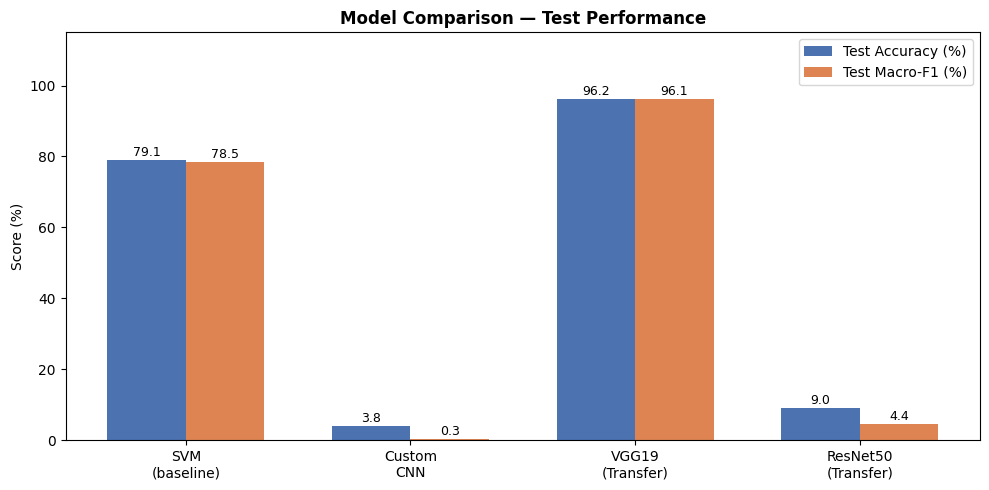

In [46]:
names     = ["SVM\n(baseline)", "Custom\nCNN", "VGG19\n(Transfer)", "ResNet50\n(Transfer)"]
test_accs = [accuracy_score(y_test, p)*100 for _, p in rows]
test_f1s  = [f1_score(y_test, p, average="macro")*100 for _, p in rows]

x = np.arange(len(names)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, test_accs, w, label="Test Accuracy (%)", color="#4C72B0")
b2 = ax.bar(x + w/2, test_f1s,  w, label="Test Macro-F1 (%)",  color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 115); ax.set_ylabel("Score (%)")
ax.set_title("Model Comparison — Test Performance", fontsize=12, fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    ax.annotate(f"{bar.get_height():.1f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
plt.show()